# Lendo a base de dados e fazendo validações

In [706]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [707]:
ibovespa = pd.read_csv(r"../data/trusted/ibovespa_historico.csv", sep=';')
ibovespa["data"] = pd.to_datetime(ibovespa["data"])
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,5.2109
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,5.2359
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,5.2196
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,5.2120
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,5.1836


In [708]:
ibovespa[["abertura", "maxima", "minima", "fechamento", "variacao_percentual"]].describe()

,abertura,maxima,minima,fechamento,variacao_percentual
count,534.000000,534.000000,534.000000,534.000000,534.000000
mean,135.653060,136.561036,134.888457,135.754279,0.067959
std,13.813322,14.069473,13.746830,14.000180,0.916199
min,118.534000,119.451000,118.223000,118.533000,-4.310000
25%,127.223000,127.871250,126.448750,127.227500,-0.447500
50%,131.168000,131.867500,130.424000,131.168500,0.050000
75%,138.852250,139.396500,137.987500,138.879750,0.590000
max,189.694000,190.561000,186.959000,189.699000,3.330000


In [709]:
# sns.boxplot(x='status', y='fechamento', data=ibovespa, palette='hls')

In [710]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,5.2109
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,5.2359
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,5.2196
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,5.2120
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,5.1836


# Feature Engineering

In [711]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,5.2109
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,5.2359
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,5.2196
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,5.2120
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,5.1836


In [712]:
ibovespa.rename(columns={'data': 'ds'}, inplace=True)

In [713]:
ibovespa.sort_values(by='ds', inplace=True)

In [714]:
ibovespa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 534 entries, 533 to 0
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ds                   534 non-null    datetime64[ns]
 1   abertura             534 non-null    float64       
 2   maxima               534 non-null    float64       
 3   minima               534 non-null    float64       
 4   fechamento           534 non-null    float64       
 5   vol_reais            534 non-null    float64       
 6   variacao_percentual  534 non-null    float64       
 7   cotacao_dia_dolar    534 non-null    float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 37.5 KB


In [715]:
# features possíveis
ibovespa["vol_log"] = np.log1p(ibovespa["vol_reais"])
ibovespa["range"] = (ibovespa["maxima"] - ibovespa["minima"]) / ibovespa["fechamento"]

In [716]:
ibovespa["body"] = (ibovespa["fechamento"] - ibovespa["abertura"]) / ibovespa["abertura"]
ibovespa["upper_shadow"] = (ibovespa["maxima"] - ibovespa["fechamento"]) / ibovespa["fechamento"]
ibovespa["lower_shadow"] = (ibovespa["fechamento"] - ibovespa["minima"]) / ibovespa["fechamento"]

Body - O tamanho do corpo do candle em termos percentuais.
fechamento > abertura - body positivo (dia comprador)
fechamento < abertura - body negativo (dia vendedor)
muito próximo - indecisão

upper_shadow - Quanto o preço subiu acima do fechamento antes de recuar.
Se for grande: O mercado subiu bastante, mas perdeu força antes de fechar. Indica pressão vendedora no topo
Significa que houve rejeição no topo.

lower_shadow - Quanto o mercado caiu durante o dia mas recuperou antes de fechar.
Houve forte pressão vendedora intraday, mas compradores reagiram. Pode indicar suporte
Mostra recuperação forte.

In [717]:
ibovespa["ret_1"] = ibovespa["variacao_percentual"]
ibovespa["ret_2"] = ibovespa["variacao_percentual"].shift(1)
ibovespa["ret_3"] = ibovespa["variacao_percentual"].shift(2)

Retorno: 
ret_1 - retorno de hoje
ret_2 - retorno de ontem
ret_3 - retorno de 2 dias atrás

In [718]:
ibovespa["volatility_5"] = ibovespa["ret_1"].rolling(5).std()

In [719]:
ibovespa["status"] = (ibovespa["variacao_percentual"].shift(-1) > 0).astype(int)

Desvio padrão dos últimos 5 retornos.

In [720]:
ibovespa.head()

,ds,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar,vol_log,range,body,upper_shadow,lower_shadow,ret_1,ret_2,ret_3,volatility_5,status
533,2024-01-02,134.186,134.195,132.095,132.697,8440000.0,-1.11,4.9235,15.948493,0.015826,-0.011097,0.011289,0.004537,-1.11,NaN,NaN,NaN,1
532,2024-01-03,132.697,133.576,132.250,132.834,8700000.0,0.10,4.9198,15.978834,0.009982,0.001032,0.005586,0.004396,0.10,-1.11,NaN,NaN,0
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,4.8968,16.009396,0.014182,-0.012083,0.012642,0.001539,-1.21,0.10,-1.11,NaN,1
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,4.8743,16.034714,0.015573,0.006135,0.004636,0.010937,0.61,-1.21,0.10,NaN,1
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,4.8700,15.955577,0.011199,0.003060,0.000536,0.010662,0.31,0.61,-1.21,0.842081,0


In [721]:
ibovespa = ibovespa.dropna()
ibovespa = ibovespa.reset_index(drop=True)
ibovespa = ibovespa.drop(columns=['abertura', 'maxima', 'minima', 'fechamento', 'vol_reais', 'variacao_percentual'])

In [722]:
ibovespa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ds                 530 non-null    datetime64[ns]
 1   cotacao_dia_dolar  530 non-null    float64       
 2   vol_log            530 non-null    float64       
 3   range              530 non-null    float64       
 4   body               530 non-null    float64       
 5   upper_shadow       530 non-null    float64       
 6   lower_shadow       530 non-null    float64       
 7   ret_1              530 non-null    float64       
 8   ret_2              530 non-null    float64       
 9   ret_3              530 non-null    float64       
 10  volatility_5       530 non-null    float64       
 11  status             530 non-null    int64         
dtypes: datetime64[ns](1), float64(10), int64(1)
memory usage: 49.8 KB


# Treinando o modelo

In [723]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## Regressão Logística

In [724]:
train = ibovespa.iloc[:-30]
test = ibovespa.iloc[-30:]

In [725]:
x_train = train.drop(columns=['ds', 'status', 'cotacao_dia_dolar'])
x_test = test.drop(columns=['ds', 'status', 'cotacao_dia_dolar'])

y_train = train['status']
y_test = test['status']

In [726]:
print(f" As datas de treino do modelo estão entre {min(train['ds'])} e {max(train['ds'])}")
print(f" As datas de validação do modelo estão entre {min(test['ds'])} e {max(test['ds'])}")

 As datas de treino do modelo estão entre 2024-01-08 00:00:00 e 2026-01-06 00:00:00
 As datas de validação do modelo estão entre 2026-01-07 00:00:00 e 2026-02-19 00:00:00


In [727]:
scaler = StandardScaler()

# Ajusta só no treino
x_train_scaled = scaler.fit_transform(x_train)

# Aplica a transformação no teste
x_test_scaled = scaler.transform(x_test)

Scaler aprende média e desvio padrão

### Fitando o modelo

In [728]:
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

In [729]:
# Avaliação
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.6333333333333333

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.60      0.25      0.35        12
           1       0.64      0.89      0.74        18

    accuracy                           0.63        30
   macro avg       0.62      0.57      0.55        30
weighted avg       0.62      0.63      0.59        30



*Classe 0 (Baixa)*

Recall 1.00: Todos de baixa foram identificados corretamente. Zero erro para quedas.

Precision 0.92: Quando o modelo previu baixa, ele acertou 92% das vezes. Houve poucos falsos alarmes de queda.

*Classe 1 (Alta)*

Recall 0.94: Ele acertou 94% das altas reais. Então errou provavelmente 1 dia de alta.

Precision 1.00: Toda vez que o modelo previu alta, ele acertou. Nenhum falso positivo para alta


In [730]:
print("Acurácia treino:", accuracy_score(y_train, model.predict(x_train_scaled)))
print("Acurácia teste:", accuracy_score(y_test, model.predict(x_test_scaled)))

Acurácia treino: 0.536
Acurácia teste: 0.6333333333333333


## Verificando a possibilidade de Overfitting

In [731]:
import numpy as np
np.random.seed(42)

y_train_shuffled = np.random.permutation(y_train)
model.fit(x_train_scaled, y_train_shuffled)
y_pred_shuffled = model.predict(x_test_scaled)

print(accuracy_score(y_test, y_pred_shuffled))

0.7


O teste de embaralhamento dos rótulos resultou em acurácia próxima de 50%, indicando ausência de vazamento de informação e sugerindo que o modelo aprendeu padrões reais no conjunto de treino. No entanto, o tamanho reduzido do conjunto de teste (30 observações) pode amplificar variações estatísticas na métrica de acurácia.

In [732]:
baseline = y_test.value_counts(normalize=True).max()
print("Baseline:", baseline)

Baseline: 0.6


Baseline é o desempenho de um modelo ingênuo, simples, que não usa nenhuma feature. 60% dos dias no teste são da classe majoritária. Então um modelo que simplesmente diga: “Todo dia vai subir” já acerta 60%.
Diferença do modelo criado: +36 pontos percentuais

In [733]:
# Veficando os coeficientes do modelo
for nome, coef in zip(x_train.columns, model.coef_[0]):
    print(nome, coef)

vol_log 0.0017866074966623696
range -0.004982227751914015
body -0.1607036399877521
upper_shadow -0.06031156674651187
lower_shadow 0.05677639871101712
ret_1 0.031045145815697565
ret_2 -0.024810814397381437
ret_3 -0.020448377574057864
volatility_5 0.1435163385204362


Se uma variável tem: coeficiente positivo → aumenta a chance de Alta (1); coeficiente negativo → aumenta a chance de Baixa (0)

In [734]:
import numpy as np
np.exp(model.coef_)

array([[1.0017882 , 0.99503016, 0.8515444 , 0.94147116, 1.05841912,
        1.03153207, 0.97549444, 0.97975927, 1.15432567]])

Significa: Um aumento de 1 desvio padrão nessa variável dobra a chance relativa de alta.

In [735]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(x_test_scaled)[:,1]
roc_auc_score(y_test, y_prob)

0.6388888888888888

	•	Modelo inicial apresentou desempenho artificialmente elevado devido a desalinhamento temporal.
	•	Após correção do target, desempenho caiu para 60%.
	•	Resultado próximo ao baseline indica baixa previsibilidade do retorno diário.
	•	Isso está alinhado com a hipótese de eficiência de mercado.

A remoção da variável de retorno defasado (ret_1) resultou em piora do desempenho do modelo, indicando que o principal sinal preditivo está associado à dinâmica de curtíssimo prazo. As demais variáveis apresentaram contribuição marginal na previsão da direção diária do índice.

Storytelling: 

Você saiu de:

“98% caramba descobri algo incrível”

Para:

“60–63%, sinal fraco mas plausível”

Isso é exatamente o processo correto em ciência de dados.

# Séries Temporais

In [736]:
ibovespa_filtrada = ibovespa.drop(columns=['abertura', 'maxima', 'minima', 'variacao_percentual', 'status_encoded'])
ibovespa_filtrada["unique_id"] = "ibovespa"

KeyError: "['abertura', 'maxima', 'minima', 'variacao_percentual', 'status_encoded'] not found in axis"

In [ ]:
ibovespa_filtrada.head()

,ds,fechamento,vol_reais,cotacao_dia_dolar,vol_log,range,unique_id
533,2024-01-02,132.697,8440000.0,4.9235,15.948493,0.015826,ibovespa
532,2024-01-03,132.834,8700000.0,4.9198,15.978834,0.009982,ibovespa
531,2024-01-04,131.226,8970000.0,4.8968,16.009396,0.014182,ibovespa
530,2024-01-05,132.023,9200000.0,4.8743,16.034714,0.015573,ibovespa
529,2024-01-08,132.427,8500000.0,4.8700,15.955577,0.011199,ibovespa


In [ ]:
treino = ibovespa_filtrada[ibovespa_filtrada['ds'] < '2026-01-07'].dropna()
valid = ibovespa_filtrada[ibovespa_filtrada['ds'] >= '2026-01-07'].dropna()
h = valid.index.nunique()

In [ ]:
print(h)

30


In [ ]:
def func_wmape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / np.abs((y_true)).sum()

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoARIMA

In [ ]:
model = StatsForecast(models=[Naive(), SeasonalNaive(season_length=7), AutoARIMA(season_length=7)], freq='D', n_jobs=-1)
model.fit(treino)

forecast_ibovespa = model.predict(h=h, level=[30])

ValueError: The following columns are missing: ['y']

In [ ]:
print(treino.dtypes)
print(valid.dtypes)
print(forecast_ibovespa.dtypes)

ds           datetime64[ns]
y                   float64
unique_id            object
dtype: object
ds           datetime64[ns]
y                   float64
unique_id            object
dtype: object
unique_id                      object
ds                     datetime64[ns]
Naive                         float64
Naive-lo-30                   float64
Naive-hi-30                   float64
SeasonalNaive                 float64
SeasonalNaive-lo-30           float64
SeasonalNaive-hi-30           float64
AutoARIMA                     float64
AutoARIMA-lo-30               float64
AutoARIMA-hi-30               float64
dtype: object


In [ ]:
forecast_ibovespa = forecast_ibovespa.merge(valid, on=["unique_id", "ds"], how="left").dropna()

wmape = func_wmape(forecast_ibovespa['y'].values, forecast_ibovespa['Naive'].values)
print (f"WMAPE Naive: {wmape: .2%}")

wmape1 = func_wmape(forecast_ibovespa['y'].values, forecast_ibovespa['SeasonalNaive'].values)
print (f"WMAPE SeasonalNaive: {wmape1: .2%}")

wmape2 = func_wmape(forecast_ibovespa['y'].values, forecast_ibovespa['AutoARIMA'].values)
print (f"WMAPE AutoARIMA: {wmape2: .2%}")

WMAPE Naive:  5.94%
WMAPE SeasonalNaive:  7.10%
WMAPE AutoARIMA:  5.70%


In [ ]:
forecast_ibovespa.head()

,unique_id,ds,Naive,Naive-lo-30,Naive-hi-30,SeasonalNaive,SeasonalNaive-lo-30,SeasonalNaive-hi-30,AutoARIMA,AutoARIMA-lo-30,AutoARIMA-hi-30,y
0,ibovespa,2026-01-07,163.664,163.063062,164.264938,160.456,158.930825,161.981175,163.786541,163.193595,164.379487,161.975
1,ibovespa,2026-01-08,163.664,162.814145,164.513855,160.897,159.371825,162.422175,163.919561,163.124092,164.715030,162.936
2,ibovespa,2026-01-09,163.664,162.623145,164.704855,160.490,158.964825,162.015175,163.897246,162.921646,164.872845,163.370
5,ibovespa,2026-01-12,163.664,162.192009,165.135991,161.870,160.344825,163.395175,164.072501,162.697293,165.447708,163.150
6,ibovespa,2026-01-13,163.664,162.074068,165.253932,163.664,162.138825,165.189175,164.291814,162.806900,165.776728,161.973


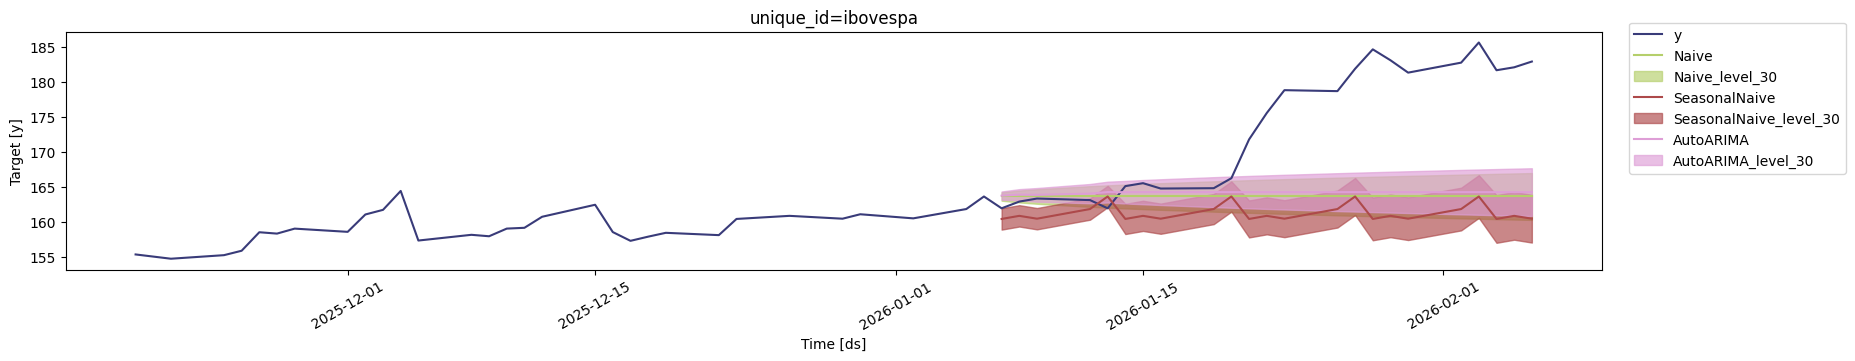

In [ ]:
model.plot(treino, forecast_ibovespa, level=[30], unique_ids=['ibovespa'], engine = 'matplotlib', max_insample_length=30)